In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from tensorflow.keras.preprocessing.image import ImageDataGenerator

import util

import sys
from pathlib import Path

# Add project root so we can import the existing student model code
project_root = Path.cwd().parents[1]
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

from ml.models.student_model import create_student_model

c:\Users\User\Sadeepa\X-Lite\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
train_df = pd.read_csv(r"C:\Users\User\Sadeepa\X-Lite\scripts\dense121\split_csv\train_df.csv")
valid_df = pd.read_csv(r"C:\Users\User\Sadeepa\X-Lite\scripts\dense121\split_csv\val_df.csv")

test_df = pd.read_csv(r"C:\Users\User\Sadeepa\X-Lite\scripts\dense121\split_csv\test_df.csv")

train_df.head()

,Image,Atelectasis,Cardiomegaly,Consolidation,Edema,Effusion,Emphysema,Fibrosis,Hernia,Infiltration,Mass,Nodule,PatientId,Pleural_Thickening,Pneumonia,Pneumothorax
0,00000003_000.png,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0
1,00000003_001.png,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0
2,00000003_002.png,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0
3,00000003_003.png,0,0,0,0,0,0,0,1,1,0,0,3,0,0,0
4,00000003_004.png,0,0,0,0,0,0,0,1,0,0,0,3,0,0,0


In [3]:
labels = ['Cardiomegaly', 
          'Emphysema', 
          'Effusion', 
          'Hernia', 
          'Infiltration', 
          'Mass', 
          'Nodule', 
          'Atelectasis',
          'Pneumothorax',
          'Pleural_Thickening', 
          'Pneumonia', 
          'Fibrosis', 
          'Edema', 
          'Consolidation']

<details>    
<summary>
    <font size="3" color="darkgreen"><b>Hints</b></font>
</summary>
<p>
<ul>
    <li> Make use of python's set.intersection() function. </li>
</ul>
</p>

In [4]:
# Checking for Data Leakage
def check_for_leakage(df1, df2, patient_col):
    
    df1_patients_unique = set(df1[patient_col].values)
    df2_patients_unique = set(df2[patient_col].values)
    
    patients_in_both_groups = df1_patients_unique.intersection(df2_patients_unique)

    leakage = len(patients_in_both_groups) > 0
    
    return leakage

In [5]:
print("leakage between train and test: {}".format(check_for_leakage(train_df, test_df, 'PatientId')))
print("leakage between valid and test: {}".format(check_for_leakage(valid_df, test_df, 'PatientId')))

leakage between train and test: False
leakage between valid and test: False


In [33]:
def get_train_generator(df, image_dir, x_col, y_cols, shuffle=True, batch_size=128, seed=1, target_w = 224, target_h = 224):
     
    print("getting train generator...") 
    # normalize images
    image_generator = ImageDataGenerator(
        samplewise_center=True,
        samplewise_std_normalization= True)
    
    # flow from directory with specified batch size
    # and target image size
    generator = image_generator.flow_from_dataframe(
            dataframe=df,
            directory=image_dir,
            x_col=x_col,
            y_col=y_cols,
            class_mode="raw",
            batch_size=batch_size,
            shuffle=shuffle,
            seed=seed,
            target_size=(target_w,target_h))
    
    return generator

In [34]:
def get_test_and_valid_generator(valid_df, test_df, train_df, image_dir, x_col, y_cols, sample_size=100, batch_size=128, seed=1, target_w = 224, target_h = 224):
    
    print("getting train and valid generators...")
    
    # Change to match the training generator EXACTLY (samplewise, not featurewise)
    image_generator = ImageDataGenerator(
        samplewise_center=True,
        samplewise_std_normalization= True)
    
    # get test generator
    valid_generator = image_generator.flow_from_dataframe(
            dataframe=valid_df,
            directory=image_dir,
            x_col=x_col,
            y_col=y_cols,
            class_mode="raw",
            batch_size=batch_size,
            shuffle=False,
            seed=seed,
            target_size=(target_w,target_h))

    test_generator = image_generator.flow_from_dataframe(
            dataframe=test_df,
            directory=image_dir,
            x_col=x_col,
            y_col=y_cols,
            class_mode="raw",
            batch_size=batch_size,
            shuffle=False,
            seed=seed,
            target_size=(target_w,target_h))
    return valid_generator, test_generator

In [35]:
IMAGE_DIR = "C:\\Users\\User\\Sadeepa\\X-Lite\\data\\clahe_cache"
train_generator = get_train_generator(train_df, IMAGE_DIR, "Image", labels)
valid_generator, test_generator= get_test_and_valid_generator(valid_df, test_df, train_df, IMAGE_DIR, "Image", labels)

getting train generator...
Found 78934 validated image filenames.
getting train and valid generators...
Found 11341 validated image filenames.
Found 21845 validated image filenames.


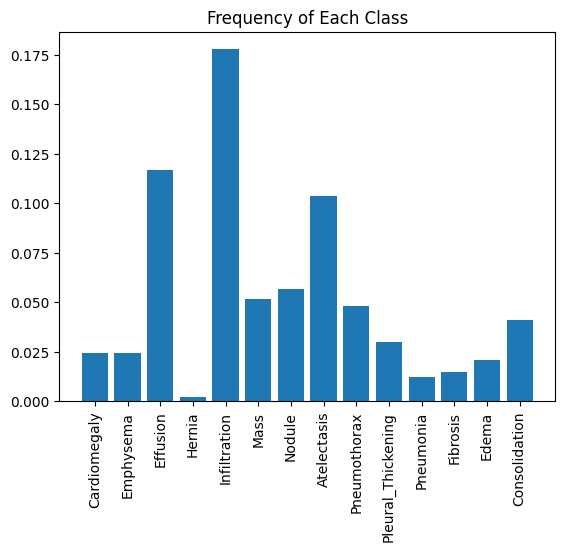

In [36]:
plt.xticks(rotation=90)
plt.bar(x=labels, height=np.mean(train_generator.labels, axis=0))
plt.title("Frequency of Each Class")
plt.show()

In [37]:
def compute_class_freqs(labels):
    
    # total number of patients (rows)
    N = labels.shape[0]
    
    positive_frequencies = np.sum(labels, axis=0) / N
    negative_frequencies = 1 - positive_frequencies

    return positive_frequencies, negative_frequencies

In [38]:
freq_pos, freq_neg = compute_class_freqs(train_generator.labels)
freq_pos

array([0.0245775 , 0.02434946, 0.11689513, 0.00217904, 0.17774343,
       0.0519548 , 0.05699698, 0.10379558, 0.04797679, 0.03011377,
       0.01254212, 0.01508855, 0.02068817, 0.04132566])

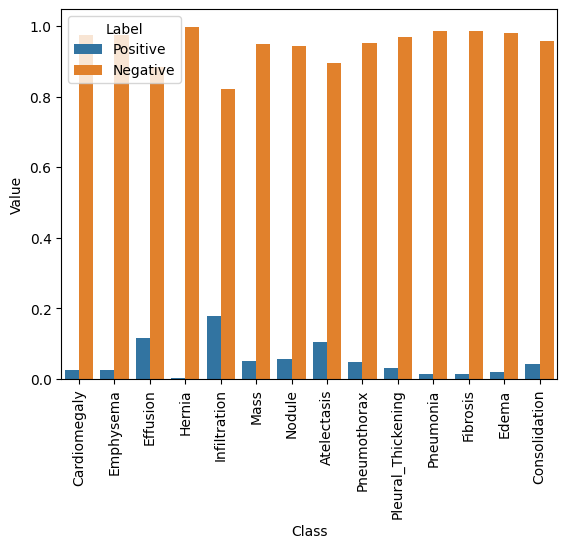

In [39]:
data = pd.DataFrame({"Class": labels, "Label": "Positive", "Value": freq_pos})
neg_data = pd.DataFrame([{"Class": labels[l], "Label": "Negative", "Value": v} for l,v in enumerate(freq_neg)])
data = pd.concat([data, neg_data], ignore_index=True)
plt.xticks(rotation=90)
f = sns.barplot(x="Class", y="Value", hue="Label" ,data=data)

In [40]:
pos_weights = freq_neg
neg_weights = freq_pos
pos_contribution = freq_pos * pos_weights 
neg_contribution = freq_neg * neg_weights

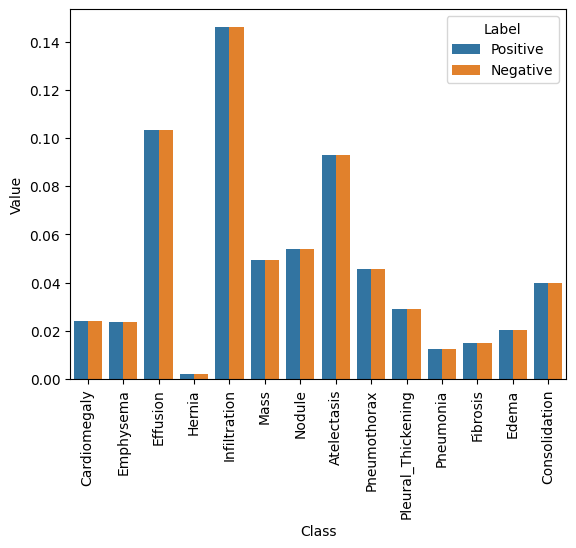

In [41]:
data = pd.DataFrame({"Class": labels, "Label": "Positive", "Value": pos_contribution})
neg_data = pd.DataFrame([{"Class": labels[l], "Label": "Negative", "Value": v} for l,v in enumerate(neg_contribution)])
data = pd.concat([data, neg_data], ignore_index=True)
plt.xticks(rotation=90)
sns.barplot(x="Class", y="Value", hue="Label" ,data=data);

In [42]:
def get_weighted_loss(pos_weights, neg_weights, epsilon=1e-7):
   
    def weighted_loss(y_true, y_pred):
    
        loss = 0.0

        for i in range(len(pos_weights)):
            # for each class, add average weighted loss for that class
            loss_pos = -1 * K.mean(pos_weights[i] * y_true[:, i] * K.log(y_pred[:, i] + epsilon))
            loss_neg = -1 * K.mean(neg_weights[i] * (1 - y_true[:, i]) * K.log(1 - y_pred[:, i] + epsilon))
            loss += loss_pos + loss_neg
        
        return loss
    
        ### END CODE HERE ###
    return weighted_loss

In [43]:
# PyTorch equivalent of the weighted Keras loss defined in Cell 16
class PyTorchWeightedLoss(nn.Module):
    def __init__(self, pos_weights, neg_weights, epsilon=1e-7):
        super().__init__()
        self.pos_weights = torch.tensor(pos_weights, dtype=torch.float32)
        self.neg_weights = torch.tensor(neg_weights, dtype=torch.float32)
        self.epsilon = epsilon
        
    def forward(self, logits, labels):
        pos_w = self.pos_weights.to(logits.device)
        neg_w = self.neg_weights.to(logits.device)
        
        # Model returns unnormalized logits, so we apply sigmoid first to get probabilities
        probs = torch.sigmoid(logits)
        
        loss_pos = -1 * pos_w * labels * torch.log(probs + self.epsilon)
        loss_neg = -1 * neg_w * (1 - labels) * torch.log(1 - probs + self.epsilon)
        
        # Mean across the batch for each class, then sum all class losses together
        return torch.mean(loss_pos + loss_neg, dim=0).sum()


In [44]:
# Build EfficientNet-B0 + Performer student model (PyTorch, CUDA only)
if not torch.cuda.is_available():
    raise RuntimeError('CUDA GPU is required for this experiment, but no GPU was detected.')

torch.backends.cudnn.benchmark = True
device = torch.device('cuda')
print(f"Using device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Keep class count aligned with the notebook's labels list (14 classes)
model = create_student_model(
    architecture='efficientnet_b0_performer',
    num_classes=len(labels),
    pretrained=True
).to(device)

criterion = PyTorchWeightedLoss(pos_weights, neg_weights)
optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total params: {total_params:,}")
print(f"Trainable params: {trainable_params:,}")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Ti SUPER


Unexpected keys (bn2.num_batches_tracked, bn2.bias, bn2.running_mean, bn2.running_var, bn2.weight, classifier.bias, classifier.weight, conv_head.weight) found while loading pretrained weights. This may be expected if model is being adapted.


Total params: 4,059,562
Trainable params: 4,059,562


<a name='4'></a>
## 4 Training [optional]

**Note** that we have already provided a pre-trained model, so you don't need to run the following training cell (as it will take some time).

With our model ready for training, we will use the `model.fit()` function in Keras to train our model. 
- We are training on a small subset of the dataset (~1%).  


In [45]:
# OPTIONAL: lightweight PyTorch training loop
import os
from PIL import Image
from sklearn.metrics import roc_auc_score
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torch.cuda.amp import autocast, GradScaler  # Used for Mixed Precision

# 1. Create a native PyTorch Dataset
class XRayDataset(Dataset):
    def __init__(self, df, image_dir, image_col, label_cols, transform=None):
        self.df = df
        self.image_dir = image_dir
        self.image_col = image_col
        self.label_cols = label_cols
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.image_dir, row[self.image_col])
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        labels = torch.tensor(row[self.label_cols].values.astype(np.float32), dtype=torch.float32)
        return image, labels

# 2. Replicate the Keras samplewise normalization in PyTorch
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Lambda(lambda x: (x - x.mean([1, 2], keepdim=True)) / (x.std([1, 2], keepdim=True) + 1e-7))
])

# 3. Initialize PyTorch Datasets and DataLoaders
train_dataset = XRayDataset(train_df, IMAGE_DIR, 'Image', labels, transform=transform)
test_dataset = XRayDataset(test_df, IMAGE_DIR, 'Image', labels, transform=transform)

# Increased batch_size to max out GPU memory capacity (change to 64 if you get CUDA OOM error)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)

num_epochs = 20
history = {'loss': [], 'test_auc': []}

# Initialize GradScaler for Automatic Mixed Precision (AMP)
scaler = GradScaler()

for epoch in range(num_epochs):
    epoch_loss = 0.0
    model.train()
    
    # Training Loop natively using the PyTorch dataloader
    for x, y in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
        # non_blocking=True explicitly allows async transfer overlapping with GPU compute
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)

        # set_to_none=True slightly increases performance and reduces overhead
        optimizer.zero_grad(set_to_none=True)
        
        # Casts operations to mixed precision (FP16) which drastically improves Tensor Core utilization
        with autocast():
            logits = model(x)
            loss = criterion(logits, y)
            
        # Unscales the gradients and calls backward
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / len(train_loader)
    history['loss'].append(avg_loss)
    
    # Test Evaluation Loop
    model.eval()
    test_preds = []
    test_labels = []
    
    with torch.no_grad():
        for x, y in tqdm(test_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Test]"):
            x = x.to(device, non_blocking=True)
            
            with autocast():
                logits = model(x)
                probs = torch.sigmoid(logits).cpu().numpy()
            
            test_preds.append(probs)
            test_labels.append(y.numpy())
            
    test_preds = np.concatenate(test_preds, axis=0)
    test_labels = np.concatenate(test_labels, axis=0)
    
    # Calculate Macro AUROC
    try:
        test_auc = roc_auc_score(test_labels, test_preds, average='macro')
    except ValueError:
        test_auc = 0.0
        
    history['test_auc'].append(test_auc)
    
    print(f"Epoch {epoch + 1}/{num_epochs} - loss: {avg_loss:.4f} - test_auc: {test_auc:.4f}")

# Plotting Loss and Test AUC
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history['loss'], label='Train Loss')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.set_title('Training Loss')

ax2.plot(history['test_auc'], label='Test AUC', color='orange')
ax2.set_ylabel('Macro AUC')
ax2.set_xlabel('Epoch')
ax2.set_title('Test AUC')
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_33064\61864128.py:52: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch 1/20 [Train]:   0%|          | 0/617 [00:00<?, ?it/s]C:\Users\User\AppData\Local\Temp\ipykernel_33064\61864128.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/20 [Train]:   0%|          | 1/617 [00:05<59:43,  5.82s/it]C:\Users\User\AppData\Local\Temp\ipykernel_33064\61864128.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch 1/20 [Train]:   0%|          | 2/617 [00:07<33:16,  3.25s/it]C:\Users\User\AppData\Local\Temp\ipykernel_33064\61864128.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)

KeyboardInterrupt: 

In [ ]:
# Optional: load a trained PyTorch checkpoint instead of Keras .h5 weights
# checkpoint_path = '../../ml/models/checkpoints/kd_student_best.pth'
# ckpt = torch.load(checkpoint_path, map_location=device, weights_only=False)
# state_dict = ckpt.get('student_state_dict', ckpt.get('model_state_dict', ckpt))
# model.load_state_dict(state_dict, strict=False)
# model.eval()

In [87]:
# Predict on test generator with PyTorch model
model.eval()
preds = []

with torch.no_grad():
    for _ in range(len(test_generator)):
        x_np, _ = next(test_generator)
        x = torch.from_numpy(x_np).permute(0, 3, 1, 2).float().to(device)
        logits = model(x)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds.append(probs)

predicted_vals = np.concatenate(preds, axis=0)
print('predicted_vals shape:', predicted_vals.shape)

predicted_vals shape: (3794, 12)


c:\Users\User\Sadeepa\X-Lite\scripts\dense121\util.py:96: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
c:\Users\User\Sadeepa\X-Lite\scripts\dense121\util.py:96: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
c:\Users\User\Sadeepa\X-Lite\scripts\dense121\util.py:96: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
c:\Users\User\Sadeepa\X-Lite\scripts\dense121\util.py:96: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
c:\Users\User\Sadeepa\X-Lite\scripts\dense121\util.py:96: UserWarning: Ignoring specified arguments in this call because figure with num: 1 already exists
  plt.figure(1, figsize=(10, 10))
c:\Users\User\Sadeepa\X-Lite\scripts\dense121\util.py:9

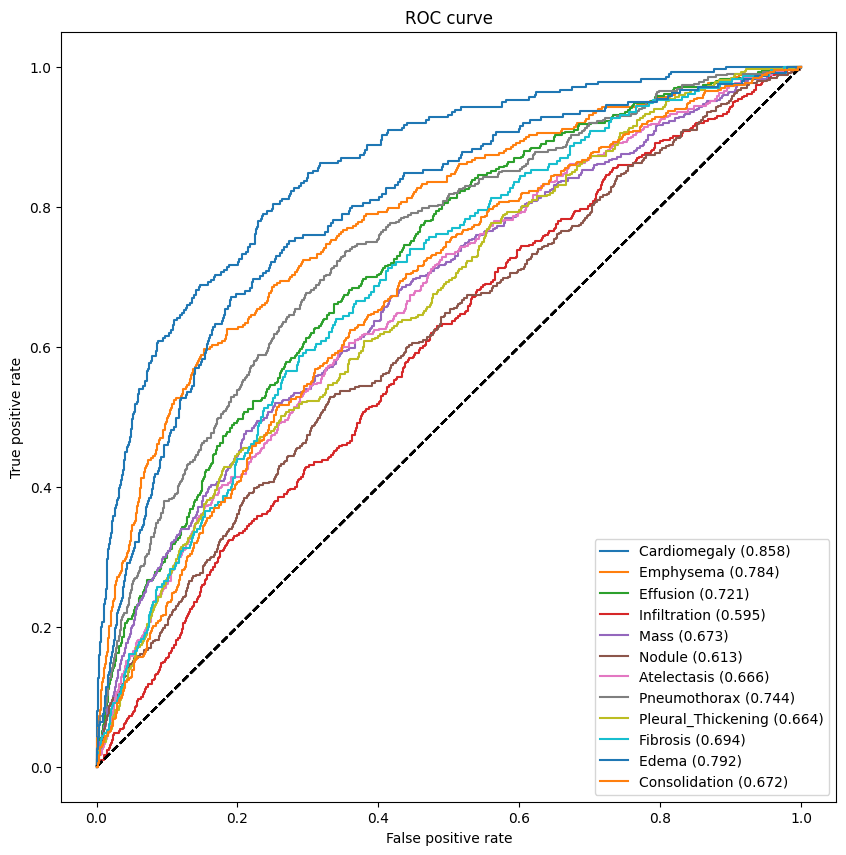

In [88]:
auc_rocs = util.get_roc_curve(labels, predicted_vals, test_generator)

For reference, here's the AUC figure from the ChexNeXt paper which includes AUC values for their model as well as radiologists on this dataset:

<img src="https://journals.plos.org/plosmedicine/article/figure/image?size=large&id=10.1371/journal.pmed.1002686.t001" width="80%">


In [ ]:
df = pd.read_csv("nih/train-small.csv")
IMAGE_DIR = "nih/images-small/"

#only show the lables with top 4 AUC
labels_to_show = np.take(labels, np.argsort(auc_rocs)[::-1])[:4]

In [ ]:
util.compute_gradcam(model, '00008270_015.png', IMAGE_DIR, df, labels, labels_to_show)

In [ ]:
util.compute_gradcam(model, '00011355_002.png', IMAGE_DIR, df, labels, labels_to_show)

In [ ]:
util.compute_gradcam(model, '00029855_001.png', IMAGE_DIR, df, labels, labels_to_show)

In [ ]:
util.compute_gradcam(model, '00005410_000.png', IMAGE_DIR, df, labels, labels_to_show)